# Pipeline GNB

In [15]:
# importazione librerie necessarie
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import gzip
import numpy as np

# modello da allenare (Gaussian Naive Bayes)
from sklearn.naive_bayes import GaussianNB

# importazione metriche di valutazione e utilità al fine dell'allenamento dei modelli
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

# per standardizzare i dati
from sklearn.preprocessing import StandardScaler

# per fare Oversampling/Undersampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

In [16]:
# features variabili su cui andare ad allenare i modelli (DA CAMBIARE PER RUN DIVERSE) [DATASET NON NORMALIZZATO]
features = ['avg_position','avg_position_1','avg_position_2','avg_position_3','avg_position_4','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features = ['avg_position','avg_position_1','avg_position_2','avg_position_3','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features = ['avg_position','avg_position_1','avg_position_2','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features = ['avg_position','avg_position_1','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features = ['avg_position','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']

In [17]:
# features variabili su cui andare ad allenare i modelli (DA CAMBIARE PER RUN DIVERSE) [DATASET NORMALIZZATO]
features_n = ['avg_position_startlist','avg_position_1_startlist','avg_position_2_startlist','avg_position_3_startlist','avg_position_4_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features_n = ['avg_position_startlist','avg_position_1_startlist','avg_position_2_startlist','avg_position_3_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features_n = ['avg_position_startlist','avg_position_1_startlist','avg_position_2_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features_n = ['avg_position_startlist','avg_position_1_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features_n = ['avg_position_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']

In [18]:
# DATA TO SAVE IN ADDITION TO CLASSIFICATION REPORT AND CONFUSION MATRIX FOR EACH MODEL

# model_name = ""
# dataset = ""
# features_dataset = []

##  Not normalized dataset

In [19]:
# Take the merged dataset cleaned from null values and anomalies
with gzip.open('../../dataset/train_set.pkl', 'r') as file:
    train_set = pickle.load(file)
with gzip.open('../../dataset/test_set.pkl', 'r') as file:
    test_set = pickle.load(file)

In [20]:
model_name = "GNB"
dataset = "dataset_non_normalizzato"
features_dataset = features

In [21]:
print("Train_set shape before dropping NaN:",train_set.shape)
print("Test_set shape before dropping NaN:",test_set.shape)
train_set = train_set.dropna()
test_set = test_set.dropna()
print("Train_set shape post dropping NaN:",train_set.shape)
print("Test_set shape post dropping NaN:",test_set.shape)

X_train = train_set[features]
y_train = train_set['top20']

X_test = test_set[features]
y_test = test_set['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (405899, 35)
Test_set shape before dropping NaN: (35406, 35)
Train_set shape post dropping NaN: (390572, 35)
Test_set shape post dropping NaN: (34258, 35)
X_train shape: (390572, 9)
y_train shape: (390572,)
X_test shape: (34258, 9)
y_test shape: (34258,)


In [22]:
# modello da allenare
GNB = GaussianNB()     

In [23]:
GNB.fit(X_train, y_train)

GaussianNB()

In [24]:
y_train_pred = GNB.predict(X_train)
scores = classification_report(y_train,y_train_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.92      0.75      0.83    336829
           1       0.28      0.61      0.39     53743

    accuracy                           0.73    390572
   macro avg       0.60      0.68      0.61    390572
weighted avg       0.83      0.73      0.77    390572



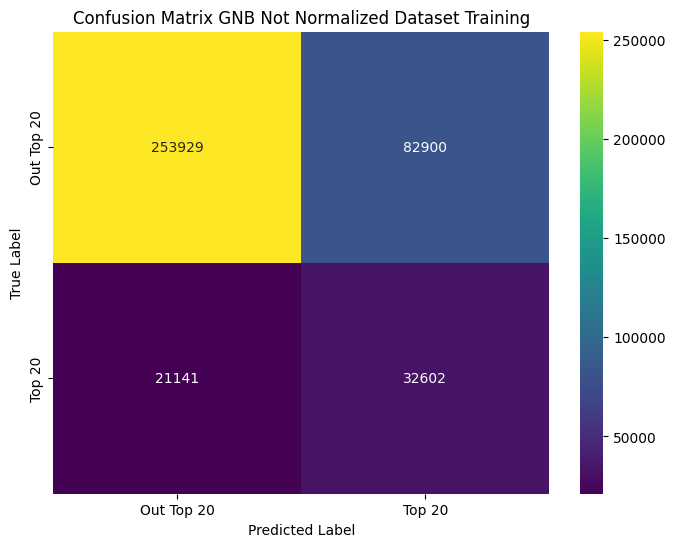

In [25]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Not Normalized Dataset Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [26]:
y_pred = GNB.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.92      0.67      0.78     29163
           1       0.27      0.68      0.38      5095

    accuracy                           0.67     34258
   macro avg       0.59      0.67      0.58     34258
weighted avg       0.82      0.67      0.72     34258



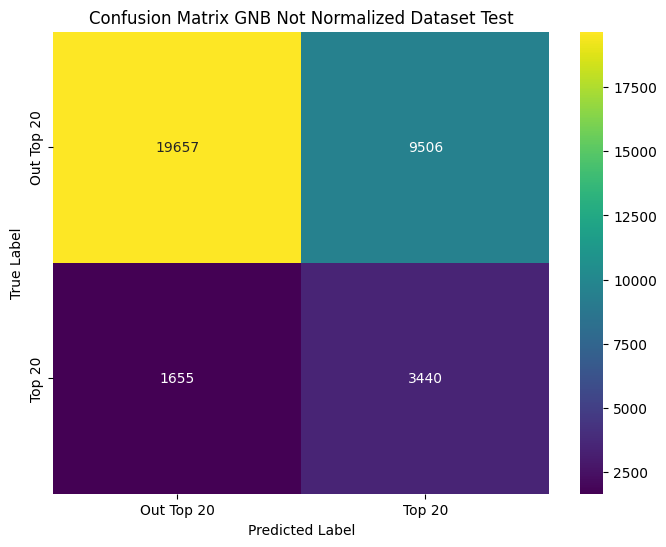

In [27]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Not Normalized Dataset Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [28]:
# # save results
# with open("./stuffs/results/GS/GNB_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

### Oversampling/Undersampling

In [29]:
model_name = "GNB"
dataset = "dataset_non_normalizzato_con_oversampling"
features_dataset = features

In [30]:
print("Train_set shape before dropping NaN:",train_set.shape)
print("Test_set shape before dropping NaN:",test_set.shape)
train_set = train_set.dropna()
test_set = test_set.dropna()
print("Train_set shape post dropping NaN:",train_set.shape)
print("Test_set shape post dropping NaN:",test_set.shape)

X_train = train_set[features]
y_train = train_set['top20']

X_test = test_set[features]
y_test = test_set['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (390572, 35)
Test_set shape before dropping NaN: (34258, 35)
Train_set shape post dropping NaN: (390572, 35)
Test_set shape post dropping NaN: (34258, 35)
X_train shape: (390572, 9)
y_train shape: (390572,)
X_test shape: (34258, 9)
y_test shape: (34258,)


In [31]:
# Controlla la distribuzione originale
print("Distribuzione originale:", Counter(y_train))

Distribuzione originale: Counter({0: 336829, 1: 53743})


In [32]:
# Applica SMOTE (Oversampling)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [33]:
# Controlla la distribuzione dopo SMOTE
print("Distribuzione dopo SMOTE:", Counter(y_train_resampled))

Distribuzione dopo SMOTE: Counter({1: 336829, 0: 336829})


In [34]:
# modello da allenare
GNB = GaussianNB()     

In [35]:
GNB.fit(X_train_resampled, y_train_resampled)

GaussianNB()

In [36]:
y_train_resampled_pred = GNB.predict(X_train_resampled)
scores = classification_report(y_train_resampled,y_train_resampled_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.69      0.63      0.66    336829
           1       0.66      0.72      0.69    336829

    accuracy                           0.67    673658
   macro avg       0.68      0.67      0.67    673658
weighted avg       0.68      0.67      0.67    673658



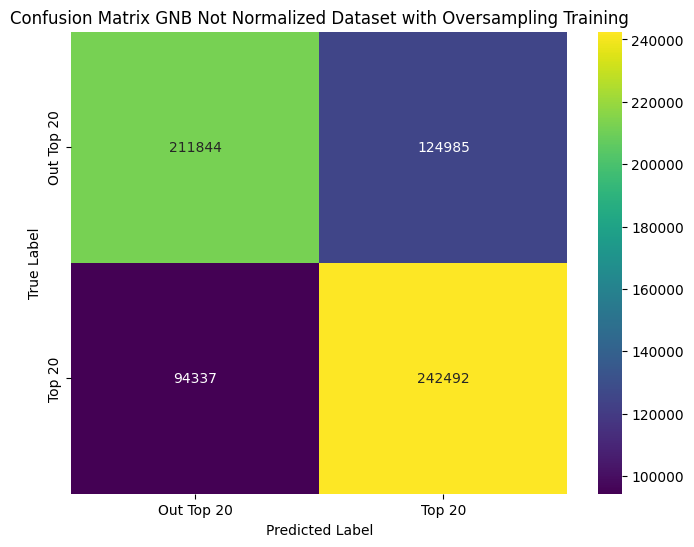

In [37]:
# confusion matrix
cm = confusion_matrix(y_train_resampled, y_train_resampled_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Not Normalized Dataset with Oversampling Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [38]:
y_pred = GNB.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.93      0.54      0.68     29163
           1       0.23      0.78      0.35      5095

    accuracy                           0.58     34258
   macro avg       0.58      0.66      0.52     34258
weighted avg       0.83      0.58      0.64     34258



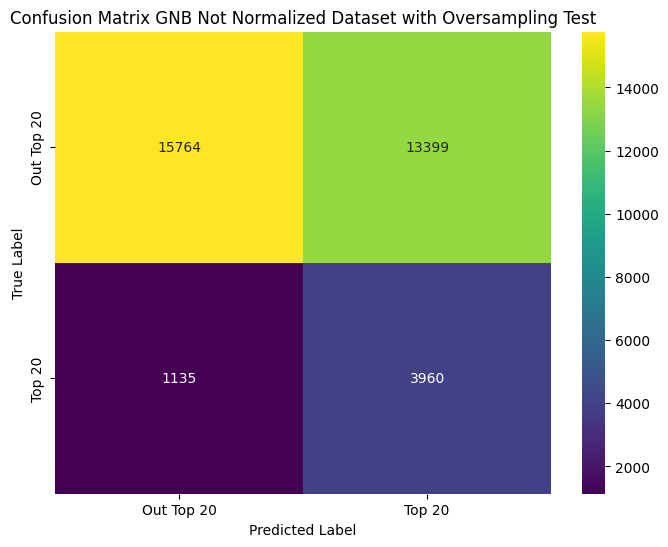

In [39]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Not Normalized Dataset with Oversampling Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [40]:
# # save results
# with open("./stuffs/results/GS/GNB_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

In [41]:
model_name = "GNB"
dataset = "dataset_non_normalizzato_con_undersampling"
features_dataset = features

In [42]:
# Controlla la distribuzione originale
print("Distribuzione originale:", Counter(y_train))

Distribuzione originale: Counter({0: 336829, 1: 53743})


In [43]:
# Applica Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

In [44]:
# Controlla la distribuzione dopo l'undersampling
print("Distribuzione dopo Random Undersampling:", Counter(y_train_resampled))

Distribuzione dopo Random Undersampling: Counter({0: 53743, 1: 53743})


In [45]:
# modello da allenare
GNB = GaussianNB()     

In [46]:
GNB.fit(X_train_resampled, y_train_resampled)

GaussianNB()

In [47]:
y_train_resampled_pred = GNB.predict(X_train_resampled)
scores = classification_report(y_train_resampled,y_train_resampled_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.69      0.63      0.66     53743
           1       0.66      0.72      0.69     53743

    accuracy                           0.67    107486
   macro avg       0.68      0.67      0.67    107486
weighted avg       0.68      0.67      0.67    107486



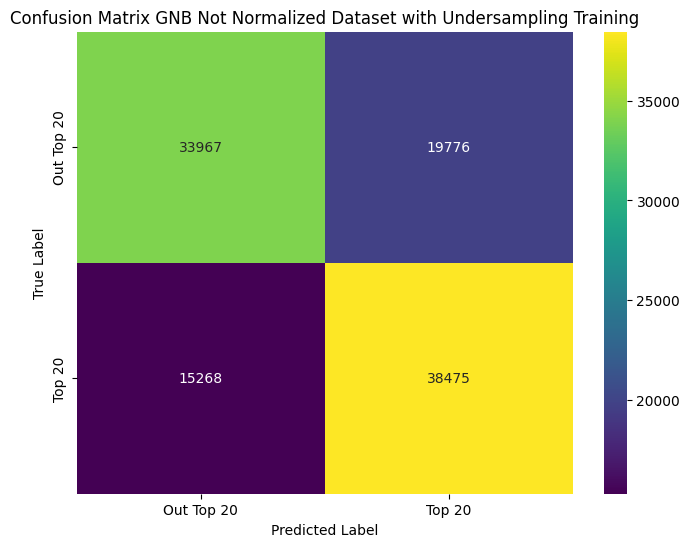

In [48]:
# confusion matrix
cm = confusion_matrix(y_train_resampled, y_train_resampled_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Not Normalized Dataset with Undersampling Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [49]:
y_pred = GNB.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.93      0.54      0.69     29163
           1       0.23      0.78      0.35      5095

    accuracy                           0.58     34258
   macro avg       0.58      0.66      0.52     34258
weighted avg       0.83      0.58      0.64     34258



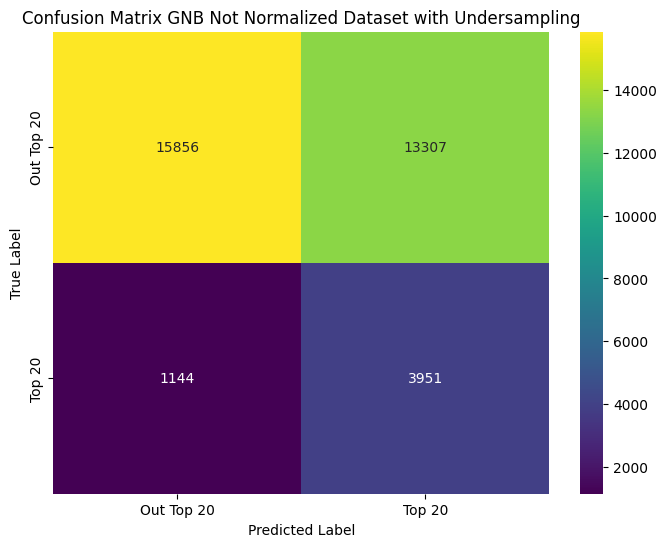

In [50]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Not Normalized Dataset with Undersampling")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [51]:
# # save results
# with open("./stuffs/results/GS/GNB_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

## Normalized dataset

In [52]:
# Take the normalized merged dataset cleaned from null values and anomalies
with gzip.open('../../dataset/train_set_normalized.pkl', 'r') as file:
    train_set_n = pickle.load(file)
with gzip.open('../../dataset/test_set_normalized.pkl', 'r') as file:
    test_set_n = pickle.load(file)

In [53]:
model_name = "GNB"
dataset = "dataset_normalizzato"
features_dataset = features_n

In [54]:
print("Train_set shape before dropping NaN:",train_set_n.shape)
print("Test_set shape before dropping NaN:",test_set_n.shape)
train_set_n = train_set_n.dropna()
test_set_n = test_set_n.dropna()
print("Train_set shape post dropping NaN:",train_set_n.shape)
print("Test_set shape post dropping NaN:",test_set_n.shape)

X_train = train_set_n[features_n]
y_train = train_set_n['top20']

X_test = test_set_n[features_n]
y_test = test_set_n['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (405899, 37)
Test_set shape before dropping NaN: (35406, 37)
Train_set shape post dropping NaN: (394206, 37)
Test_set shape post dropping NaN: (34509, 37)
X_train shape: (394206, 9)
y_train shape: (394206,)
X_test shape: (34509, 9)
y_test shape: (34509,)


In [55]:
# modello da allenare
GNB = GaussianNB()  

In [56]:
GNB.fit(X_train, y_train)

GaussianNB()

In [57]:
y_train_pred = GNB.predict(X_train)
scores = classification_report(y_train,y_train_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.92      0.74      0.82    340134
           1       0.27      0.61      0.38     54072

    accuracy                           0.72    394206
   macro avg       0.60      0.68      0.60    394206
weighted avg       0.83      0.72      0.76    394206



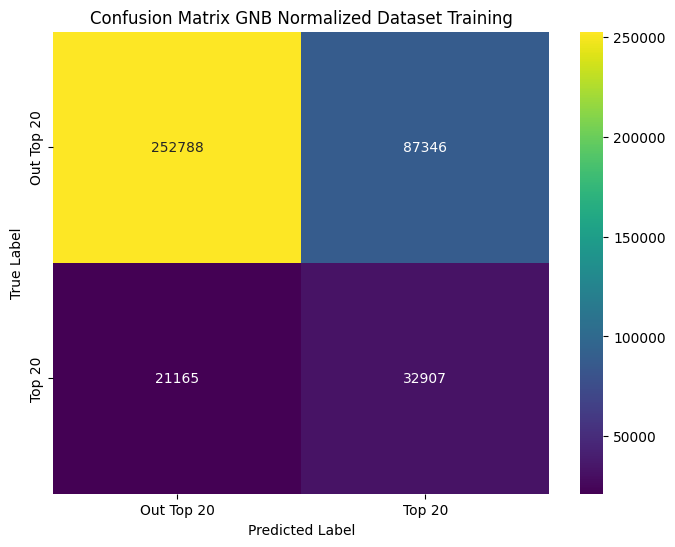

In [58]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Normalized Dataset Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [59]:
y_pred = GNB.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.91      0.74      0.82     29391
           1       0.29      0.59      0.39      5118

    accuracy                           0.72     34509
   macro avg       0.60      0.67      0.60     34509
weighted avg       0.82      0.72      0.76     34509



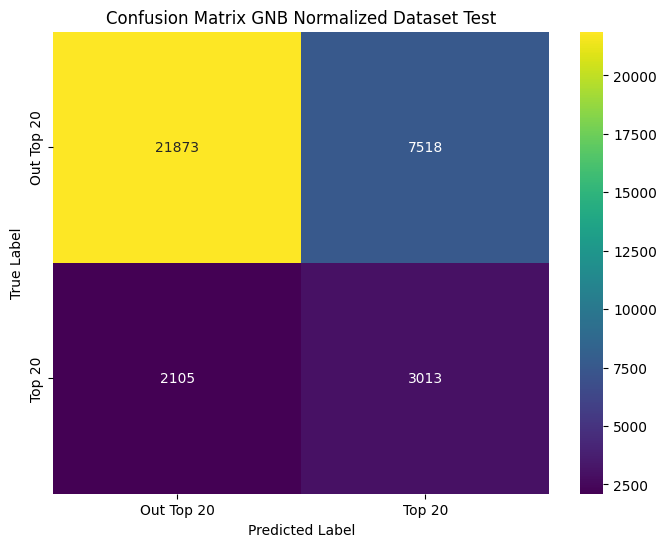

In [60]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Normalized Dataset Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [61]:
# # save results
# with open("./stuffs/results/GS/GNB_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

### Oversampling/Undersampling

In [62]:
model_name = "GNB"
dataset = "dataset_normalizzato_con_oversampling"
features_dataset = features_n

In [63]:
print("Train_set shape before dropping NaN:",train_set_n.shape)
print("Test_set shape before dropping NaN:",test_set_n.shape)
train_set_n = train_set_n.dropna()
test_set_n = test_set_n.dropna()
print("Train_set shape post dropping NaN:",train_set_n.shape)
print("Test_set shape post dropping NaN:",test_set_n.shape)

X_train = train_set_n[features_n]
y_train = train_set_n['top20']

X_test = test_set_n[features_n]
y_test = test_set_n['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (394206, 37)
Test_set shape before dropping NaN: (34509, 37)
Train_set shape post dropping NaN: (394206, 37)
Test_set shape post dropping NaN: (34509, 37)
X_train shape: (394206, 9)
y_train shape: (394206,)
X_test shape: (34509, 9)
y_test shape: (34509,)


In [64]:
# Controlla la distribuzione originale
print("Distribuzione originale:", Counter(y_train))

Distribuzione originale: Counter({0: 340134, 1: 54072})


In [65]:
# Applica SMOTE (Oversampling)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [66]:
# Controlla la distribuzione dopo SMOTE
print("Distribuzione dopo SMOTE:", Counter(y_train_resampled))

Distribuzione dopo SMOTE: Counter({1: 340134, 0: 340134})


In [67]:
# modello da allenare
GNB = GaussianNB()     

In [68]:
GNB.fit(X_train_resampled, y_train_resampled)

GaussianNB()

In [69]:
y_train_resampled_pred = GNB.predict(X_train_resampled)
scores = classification_report(y_train_resampled,y_train_resampled_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.71      0.57      0.63    340134
           1       0.64      0.77      0.70    340134

    accuracy                           0.67    680268
   macro avg       0.68      0.67      0.67    680268
weighted avg       0.68      0.67      0.67    680268



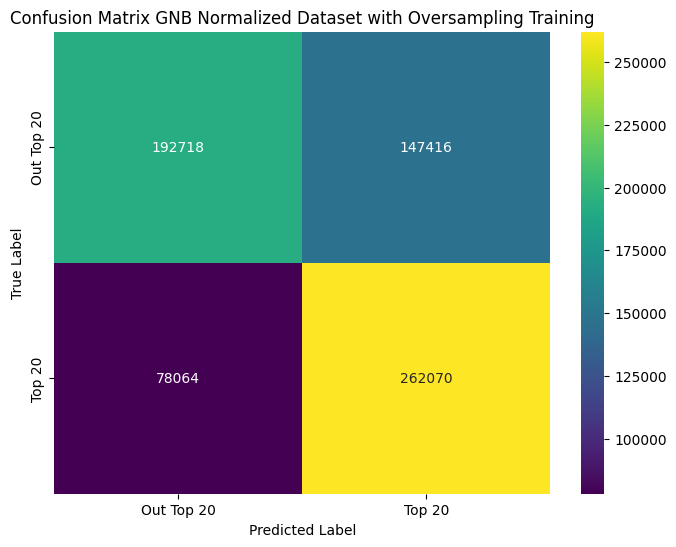

In [70]:
# confusion matrix
cm = confusion_matrix(y_train_resampled, y_train_resampled_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Normalized Dataset with Oversampling Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [71]:
y_pred = GNB.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.92      0.61      0.73     29391
           1       0.24      0.71      0.36      5118

    accuracy                           0.62     34509
   macro avg       0.58      0.66      0.54     34509
weighted avg       0.82      0.62      0.68     34509



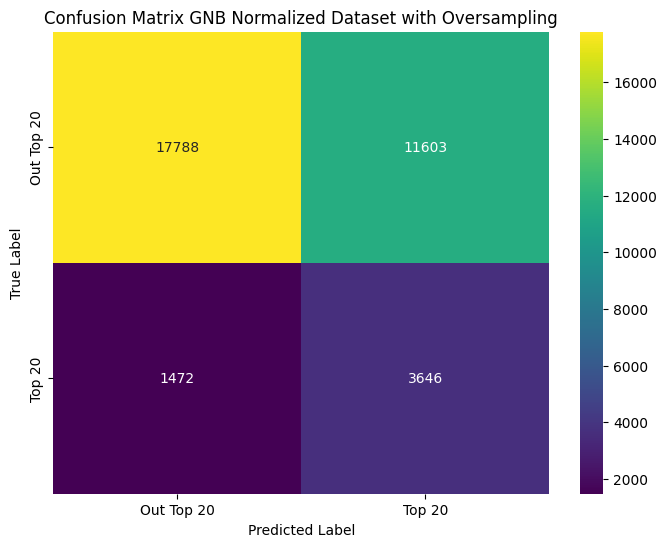

In [72]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Normalized Dataset with Oversampling")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [73]:
# # save results
# with open("./stuffs/results/GS/GNB_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

In [74]:
model_name = "GNB"
dataset = "dataset_normalizzato_con_undersampling"
features_dataset = features_n

In [75]:
# Controlla la distribuzione originale
print("Distribuzione originale:", Counter(y_train))

Distribuzione originale: Counter({0: 340134, 1: 54072})


In [76]:
# Applica Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

In [77]:
# Controlla la distribuzione dopo l'undersampling
print("Distribuzione dopo Random Undersampling:", Counter(y_train_resampled))

Distribuzione dopo Random Undersampling: Counter({0: 54072, 1: 54072})


In [78]:
# modello da allenare
GNB = GaussianNB()     

In [79]:
GNB.fit(X_train_resampled, y_train_resampled)

GaussianNB()

In [80]:
y_train_resampled_pred = GNB.predict(X_train_resampled)
scores = classification_report(y_train_resampled,y_train_resampled_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.69      0.59      0.64     54072
           1       0.64      0.74      0.69     54072

    accuracy                           0.66    108144
   macro avg       0.67      0.66      0.66    108144
weighted avg       0.67      0.66      0.66    108144



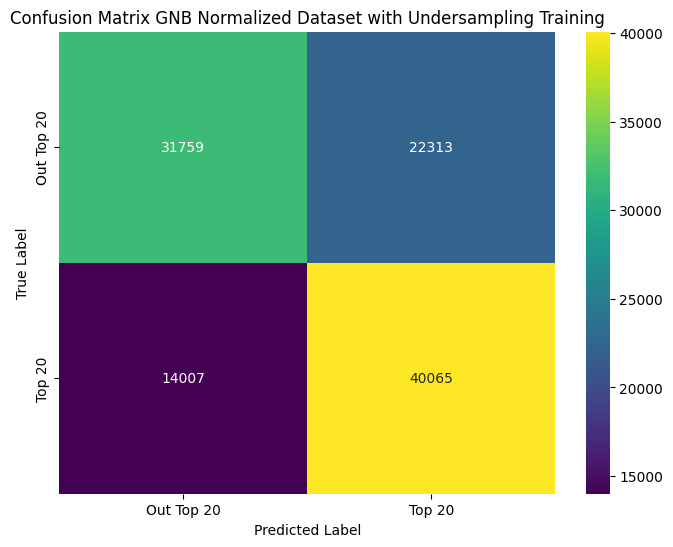

In [81]:
# confusion matrix
cm = confusion_matrix(y_train_resampled, y_train_resampled_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Normalized Dataset with Undersampling Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [82]:
y_pred = GNB.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.92      0.62      0.74     29391
           1       0.24      0.71      0.36      5118

    accuracy                           0.63     34509
   macro avg       0.58      0.66      0.55     34509
weighted avg       0.82      0.63      0.69     34509



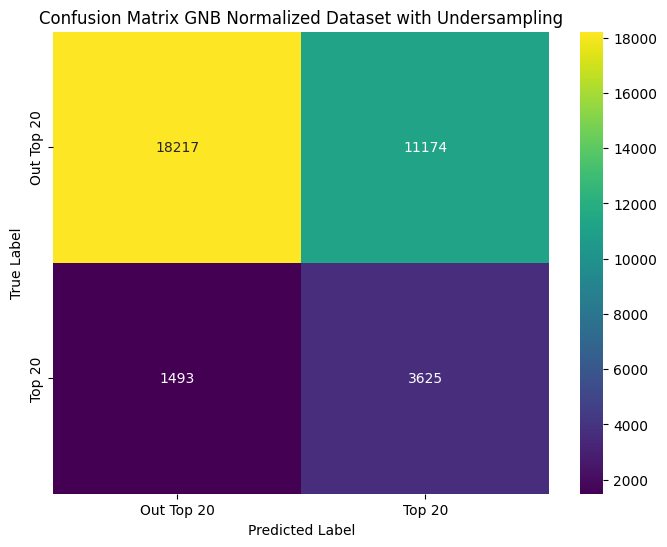

In [83]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Normalized Dataset with Undersampling")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [84]:
# # save results
# with open("./stuffs/results/GS/GNB_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

## Standardizzazione datasets

###  Not normalized dataset

In [85]:
# Take the merged dataset cleaned from null values and anomalies
with gzip.open('../../dataset/train_set.pkl', 'r') as file:
    train_set = pickle.load(file)
with gzip.open('../../dataset/test_set.pkl', 'r') as file:
    test_set = pickle.load(file)

In [86]:
model_name = "GNB"
dataset = "dataset_non_normalizzato_standardizzato"
features_dataset = features

In [87]:
print("Train_set shape before dropping NaN:",train_set.shape)
print("Test_set shape before dropping NaN:",test_set.shape)
train_set = train_set.dropna()
test_set = test_set.dropna()
print("Train_set shape post dropping NaN:",train_set.shape)
print("Test_set shape post dropping NaN:",test_set.shape)

X_train = train_set[features]
y_train = train_set['top20']

X_test = test_set[features]
y_test = test_set['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (405899, 35)
Test_set shape before dropping NaN: (35406, 35)
Train_set shape post dropping NaN: (390572, 35)
Test_set shape post dropping NaN: (34258, 35)
X_train shape: (390572, 9)
y_train shape: (390572,)
X_test shape: (34258, 9)
y_test shape: (34258,)


In [88]:
X_train

,avg_position,avg_position_1,avg_position_2,avg_position_3,avg_position_4,performance_wma,top20_consistency,races_dby_consistency,participants
436,9.250000,4.0,12.5,9.333333,9.25,9.111111,3.0,1.333333,106
437,12.750000,6.0,9.0,8.000000,12.75,13.555556,3.0,1.333333,106
438,48.750000,31.0,49.0,45.666667,48.75,48.185185,0.0,4.000000,106
439,27.250000,36.0,37.0,36.000000,27.25,25.777778,1.0,4.000000,106
440,32.750000,23.0,29.0,27.333333,32.75,33.518519,0.0,4.000000,106
...,...,...,...,...,...,...,...,...,...
405893,82.486486,56.0,78.5,91.666667,97.00,88.287693,20.0,14.800000,107
405894,57.066667,60.0,39.0,29.000000,28.25,38.394198,2.0,7.500000,107
405896,79.868421,67.0,78.5,80.333333,81.75,80.619584,4.0,19.000000,107
405897,81.847518,153.0,153.5,151.333333,151.50,150.315647,12.0,23.500000,107


In [89]:
# Standardizza i dati (fondamentale per il modello Gaussian Naive Bayes che si aspetta che i dati seguano una distribuzione gaussiana (normale))
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [90]:
X_train

array([[-2.89447006, -1.54667167, -1.63430766, ..., -0.55021606,
        -0.7187024 , -2.12732694],
       [-2.75129168, -1.50570027, -1.71964158, ..., -0.55021606,
        -0.7187024 , -2.12732694],
       [-1.27859974, -0.99355773, -0.74439682, ..., -0.63987051,
        -0.5806216 , -2.12732694],
       ...,
       [-0.00560397, -0.25607248, -0.0251538 , ..., -0.52033125,
         0.19608286, -2.0886307 ],
       [ 0.07535713,  1.50569785,  1.80343012, ..., -0.28125272,
         0.4290942 , -2.0886307 ],
       [ 0.96333997, -0.03072976,  0.52342137, ..., -0.40079199,
         1.47764522, -2.0886307 ]])

In [91]:
# modello da allenare
GNB = GaussianNB()     

In [92]:
GNB.fit(X_train, y_train)

GaussianNB()

In [93]:
y_train_pred = GNB.predict(X_train)
scores = classification_report(y_train,y_train_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.92      0.75      0.83    336829
           1       0.28      0.61      0.39     53743

    accuracy                           0.73    390572
   macro avg       0.60      0.68      0.61    390572
weighted avg       0.83      0.73      0.77    390572



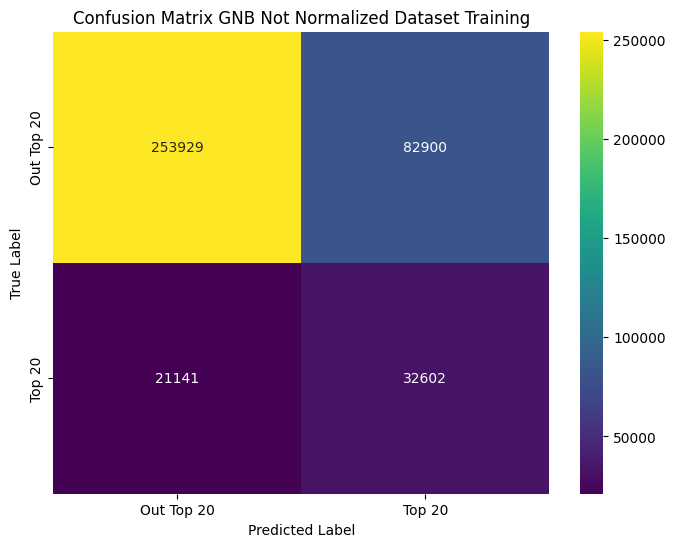

In [94]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Not Normalized Dataset Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [95]:
y_pred = GNB.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.92      0.67      0.78     29163
           1       0.27      0.68      0.38      5095

    accuracy                           0.67     34258
   macro avg       0.59      0.67      0.58     34258
weighted avg       0.82      0.67      0.72     34258



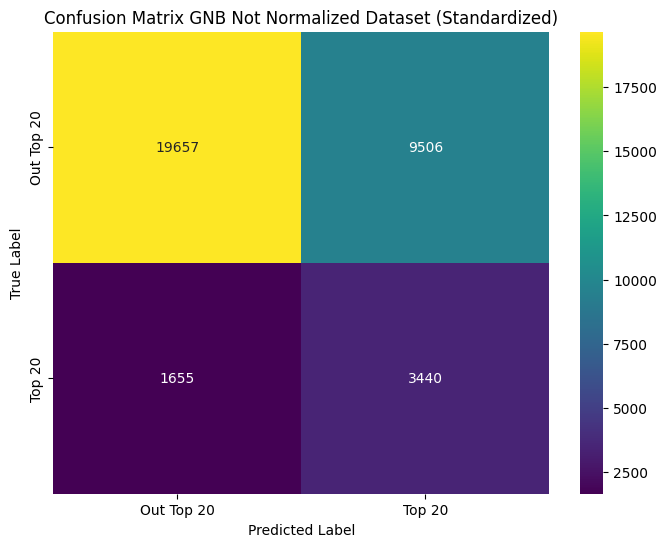

In [96]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Not Normalized Dataset (Standardized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [97]:
# # save results
# with open("./stuffs/results/GS/GNB_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

### Normalized dataset

In [98]:
# Take the normalized merged dataset cleaned from null values and anomalies
with gzip.open('../../dataset/train_set_normalized.pkl', 'r') as file:
    train_set_n = pickle.load(file)
with gzip.open('../../dataset/test_set_normalized.pkl', 'r') as file:
    test_set_n = pickle.load(file)

In [99]:
model_name = "GNB"
dataset = "dataset_normalizzato_standardizzato"
features_dataset = features_n

In [100]:
print("Train_set shape before dropping NaN:",train_set_n.shape)
print("Test_set shape before dropping NaN:",test_set_n.shape)
train_set_n = train_set_n.dropna()
test_set_n = test_set_n.dropna()
print("Train_set shape post dropping NaN:",train_set_n.shape)
print("Test_set shape post dropping NaN:",test_set_n.shape)

X_train = train_set_n[features_n]
y_train = train_set_n['top20']

X_test = test_set_n[features_n]
y_test = test_set_n['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (405899, 37)
Test_set shape before dropping NaN: (35406, 37)
Train_set shape post dropping NaN: (394206, 37)
Test_set shape post dropping NaN: (34509, 37)
X_train shape: (394206, 9)
y_train shape: (394206,)
X_test shape: (34509, 9)
y_test shape: (34509,)


In [101]:
X_train

,avg_position_startlist,avg_position_1_startlist,avg_position_2_startlist,avg_position_3_startlist,avg_position_4_startlist,performance_wma,top20_consistency,races_dby_consistency,participants
328,0.002149,0.000806,0.000806,0.002149,0.002149,0.029339,3.0,1.00,108
329,0.035455,0.048348,0.046334,0.035455,0.035455,0.364304,1.0,3.00,108
330,0.002417,0.000000,0.003626,0.002417,0.002417,0.018349,3.0,1.00,108
331,0.053720,0.081386,0.068896,0.053720,0.053720,0.568752,0.0,3.00,108
332,0.046468,0.035455,0.052780,0.046468,0.046468,0.481624,0.0,3.00,108
...,...,...,...,...,...,...,...,...,...
405893,0.083004,0.054741,0.076735,0.089606,0.094819,0.601824,20.0,14.80,107
405894,0.068649,0.089552,0.058209,0.043284,0.042164,0.285428,2.0,7.50,107
405896,0.100568,0.103876,0.108900,0.108043,0.108247,0.673784,4.0,19.00,107
405897,0.087904,0.172881,0.173446,0.170998,0.171186,0.847997,12.0,23.50,107


In [102]:
# Standardizza i dati (fondamentale per il modello Gaussian Naive Bayes che si aspetta che i dati seguano una distribuzione gaussiana (normale))
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [103]:
X_train

array([[-2.43993808, -1.43362194, -1.65680703, ..., -0.54590959,
        -0.73212075, -2.04732674],
       [-1.30654645, -0.49139233, -0.61431717, ..., -0.60584625,
        -0.62827319, -2.04732674],
       [-2.43079783, -1.44959194, -1.59222801, ..., -0.54590959,
        -0.73212075, -2.04732674],
       ...,
       [ 0.90919462,  0.60910117,  0.8183206 , ..., -0.51594126,
         0.20250727, -2.08595455],
       [ 0.47824028,  1.97670251,  2.2962941 , ..., -0.27619463,
         0.43616428, -2.08595455],
       [ 0.99711675,  0.12460708,  0.09662377, ..., -0.39606794,
         1.48762081, -2.08595455]])

In [104]:
# modello da allenare
GNB = GaussianNB()  

In [105]:
GNB.fit(X_train, y_train)

GaussianNB()

In [106]:
y_train_pred = GNB.predict(X_train)
scores = classification_report(y_train,y_train_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.92      0.74      0.82    340134
           1       0.27      0.61      0.38     54072

    accuracy                           0.72    394206
   macro avg       0.60      0.68      0.60    394206
weighted avg       0.83      0.72      0.76    394206



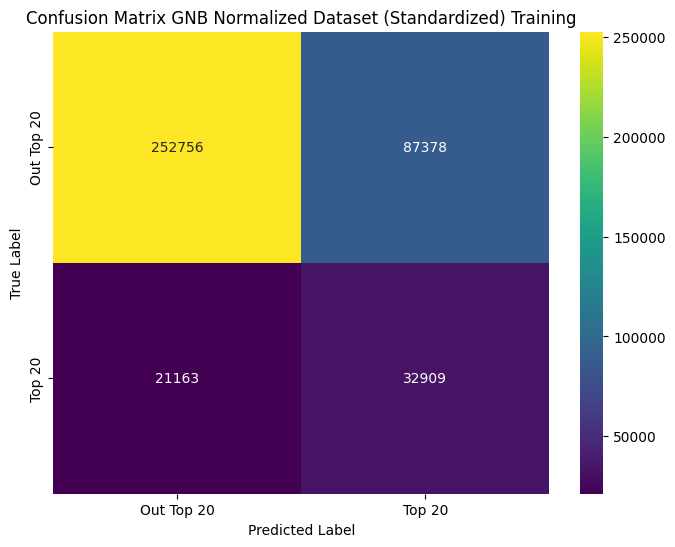

In [107]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Normalized Dataset (Standardized) Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [108]:
y_pred = GNB.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.91      0.74      0.82     29391
           1       0.29      0.59      0.39      5118

    accuracy                           0.72     34509
   macro avg       0.60      0.67      0.60     34509
weighted avg       0.82      0.72      0.76     34509



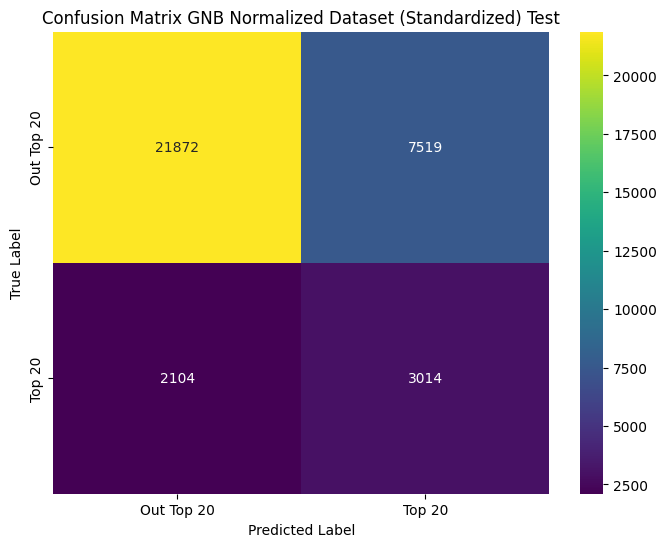

In [109]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Normalized Dataset (Standardized) Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [110]:
# # save results
# with open("./stuffs/results/GS/GNB_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")